In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imagecas/601-800.change2zip
/kaggle/input/imagecas/201-400.z02
/kaggle/input/imagecas/imageCAS_data_split.xlsx
/kaggle/input/imagecas/401-600.z03
/kaggle/input/imagecas/801-1000.z04
/kaggle/input/imagecas/801-1000.z02
/kaggle/input/imagecas/801-1000.change2zip
/kaggle/input/imagecas/401-600.z02
/kaggle/input/imagecas/201-400.z01
/kaggle/input/imagecas/801-1000.z01
/kaggle/input/imagecas/1-200.z01
/kaggle/input/imagecas/601-800.z04
/kaggle/input/imagecas/601-800.z03
/kaggle/input/imagecas/601-800.z01
/kaggle/input/imagecas/201-400.z03
/kaggle/input/imagecas/1-200.z03
/kaggle/input/imagecas/401-600.change2zip
/kaggle/input/imagecas/1-200.z02
/kaggle/input/imagecas/1-200.z04
/kaggle/input/imagecas/201-400.change2zip
/kaggle/input/imagecas/601-800.z02
/kaggle/input/imagecas/1-200.change2zip
/kaggle/input/imagecas/801-1000.z03
/kaggle/input/imagecas/201-400.z04
/kaggle/input/imagecas/401-600.z04
/kaggle/input/imagecas/401-600.z01
/kaggle/input/imagecas/Coronary_Segmentation_de

In [2]:
!pip install monai
!pip install lmdb
!pip install mlflow
!pip install pynrrd
!pip install clearml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.2/28.2 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.3/692.3 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.4 MB/s eta 0:00:00
  Attempting uninstall: pyjwt
    Found existing install

In [3]:
!python -c "import monai" || pip install -q "monai-weekly[ignite, nibabel, tensorboard, mlflow]"

2025-04-20 17:25:46.523879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-20 17:25:46.710256: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-20 17:25:46.765282: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
import glob
import logging
import os
from pathlib import Path
import shutil
import sys
import tempfile

import nibabel as nib
import numpy as np
from monai.config import print_config
from monai.data import ArrayDataset, create_test_image_3d, decollate_batch, DataLoader
from monai.handlers import (
    MeanDice,
    MLFlowHandler,
    StatsHandler,
    TensorBoardImageHandler,
    TensorBoardStatsHandler,
)
from monai.losses import DiceLoss
from monai.networks.nets import UNet
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandSpatialCrop,
    Resize,
    ScaleIntensity,
)
from monai.utils import first

import ignite
import torch

from monai import transforms
from monai.transforms import (
    AsDiscrete,
    Activations,
)

import os
import json
import shutil
import tempfile
import time

import matplotlib.pyplot as plt

from monai.inferers import sliding_window_inference
from monai import transforms

from monai.config import print_config
from monai.metrics import DiceMetric
from monai.utils.enums import MetricReduction
from monai.networks.nets import SwinUNETR
from monai.networks.nets import UNETR
from monai import data
from monai.data import decollate_batch
from functools import partial

import torch
import os, glob

from torch.utils.data import DataLoader, random_split
from monai.data import ArrayDataset
from monai.transforms import Compose, LoadImage, EnsureChannelFirst, ScaleIntensity, ToTensor

from monai.handlers.utils import from_engine
from monai.networks.nets import UNet,SegResNet,SegResNetVAE,AttentionUnet
from monai.networks.layers import Norm
from monai.networks.nets import HighResNet

from monai import data
from monai.data import decollate_batch
from functools import partial
from monai.networks.nets import DynUNet
from monai.networks.nets import VNet
import torch
from monai.networks.nets import SegResNetVAE
import torch.nn.functional as F

print_config()

MONAI version: 1.4.0
Numpy version: 1.26.4
Pytorch version: 2.5.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 46a5272196a6c2590ca2589029eed8e4d56ff008
MONAI __file__: /usr/local/lib/python3.10/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.1
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.25.0
scipy version: 1.13.1
Pillow version: 11.0.0
Tensorboard version: 2.17.1
gdown version: 5.2.0
TorchVision version: 0.20.1+cu121
tqdm version: 4.67.1
lmdb version: 1.6.2
psutil version: 5.9.5
pandas version: 2.2.3
einops version: 0.8.0
transformers version: 4.47.0
mlflow version: 2.21.3
pynrrd version: 1.1.3
clearml version: 1.18.0

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [5]:
fold = 1
roi = (96, 96, 96)
batch_size = 1
num_crop_samples=4

In [6]:
import os
import tempfile

directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmpd80ya4e5


In [7]:
! df -ha

Filesystem                                                             Size  Used Avail Use% Mounted on
overlay                                                                7.9T  6.2T  1.8T  78% /
proc                                                                      0     0     0    - /proc
tmpfs                                                                   64M     0   64M   0% /dev
devpts                                                                    0     0     0    - /dev/pts
sysfs                                                                     0     0     0    - /sys
cgroup                                                                    0     0     0    - /sys/fs/cgroup
mqueue                                                                    0     0     0    - /dev/mqueue
shm                                                                     14G  4.0K   14G   1% /dev/shm
/dev/loop1                                                              20G  220K   20G  

In [8]:
! du -sh /kaggle/input/imagecas/*.*z*

770M	/kaggle/input/imagecas/1-200.change2zip
4.0G	/kaggle/input/imagecas/1-200.z01
4.0G	/kaggle/input/imagecas/1-200.z02
4.0G	/kaggle/input/imagecas/1-200.z03
4.0G	/kaggle/input/imagecas/1-200.z04
674M	/kaggle/input/imagecas/201-400.change2zip
4.0G	/kaggle/input/imagecas/201-400.z01
4.0G	/kaggle/input/imagecas/201-400.z02
4.0G	/kaggle/input/imagecas/201-400.z03
4.0G	/kaggle/input/imagecas/201-400.z04
705M	/kaggle/input/imagecas/401-600.change2zip
4.0G	/kaggle/input/imagecas/401-600.z01
4.0G	/kaggle/input/imagecas/401-600.z02
4.0G	/kaggle/input/imagecas/401-600.z03
4.0G	/kaggle/input/imagecas/401-600.z04
273M	/kaggle/input/imagecas/601-800.change2zip
4.0G	/kaggle/input/imagecas/601-800.z01
4.0G	/kaggle/input/imagecas/601-800.z02
4.0G	/kaggle/input/imagecas/601-800.z03
4.0G	/kaggle/input/imagecas/601-800.z04
639M	/kaggle/input/imagecas/801-1000.change2zip
4.0G	/kaggle/input/imagecas/801-1000.z01
4.0G	/kaggle/input/imagecas/801-1000.z02
4.0G	/kaggle/input/imagecas/801-1000.z03
4.0G	/kaggl

In [9]:
from pathlib import Path
import shutil
import sys, os

TMP_DIR = Path("/kaggle/working/imagecas")
TMP_DIR.mkdir(parents=True, exist_ok=True)

czips = list(Path("/kaggle/input/imagecas/").rglob("*.*z*"))
for f in czips:
    # Check if the file name starts with "1-200"
    if f.name.startswith("1-200"):
        ext = f.suffix if f.suffix != ".change2zip" else ".zip"
        target = TMP_DIR / f"{f.stem}{ext}"
        print(f, target)
        if not target.exists():
            os.symlink(f, target)

/kaggle/input/imagecas/1-200.z01 /kaggle/working/imagecas/1-200.z01
/kaggle/input/imagecas/1-200.z03 /kaggle/working/imagecas/1-200.z03
/kaggle/input/imagecas/1-200.z02 /kaggle/working/imagecas/1-200.z02
/kaggle/input/imagecas/1-200.z04 /kaggle/working/imagecas/1-200.z04
/kaggle/input/imagecas/1-200.change2zip /kaggle/working/imagecas/1-200.zip


In [10]:
! df -h

Filesystem                                                             Size  Used Avail Use% Mounted on
overlay                                                                7.9T  6.2T  1.8T  78% /
tmpfs                                                                   64M     0   64M   0% /dev
shm                                                                     14G  4.0K   14G   1% /dev/shm
/dev/loop1                                                              20G  232K   20G   1% /kaggle/src
192.168.7.2:/data/kagglesdsdata/datasets/3937305/7086150/d99wdiwkg1b2   80T   63T   18T  78% /kaggle/input/imagecas
/dev/sdb1                                                              122G  4.9G  117G   4% /opt/bin
/dev/mapper/snap                                                       7.9T  6.2T  1.8T  78% /etc/hosts
tmpfs                                                                   16G     0   16G   0% /proc/acpi
tmpfs                                                                 

In [11]:
from tqdm import tqdm
import shutil

TARGET_DIR = Path("/kaggle/temp/imagecas/unzip_space")
shutil.rmtree(TARGET_DIR, ignore_errors=True)
TARGET_DIR.mkdir(parents=True, exist_ok=True)

zips = list(TMP_DIR.rglob("*.zip"))
for z in tqdm(zips):
    z_full = z.with_stem(f"{z.stem}_full")
    print(z_full)
    ! zip -FF {z} --out {z_full}
    ! du -sh /kaggle/temp/imagecas/*
    ! unzip {z_full} -d {TARGET_DIR}
    ! rm {z_full}
    ! du -sh /kaggle/temp/imagecas/*
    ! ls {TARGET_DIR}

!pwd

  0%|          | 0/1 [00:00<?, ?it/s]

/kaggle/working/imagecas/1-200_full.zip
Fix archive (-FF) - salvage what can
 Found end record (EOCDR) - says expect 5 splits
Scanning for entries...
  Found spanning marker - expected as this is split (multi-disk) archive...
 copying: 1-200/  (0 bytes)
 copying: 1-200/1.img.nii.gz  (95776133 bytes)
 copying: 1-200/1.label.nii.gz  (125576 bytes)
 copying: 1-200/10.img.nii.gz  (97656072 bytes)
 copying: 1-200/10.label.nii.gz  (117894 bytes)
 copying: 1-200/100.img.nii.gz  (73461698 bytes)
 copying: 1-200/100.label.nii.gz  (169202 bytes)
 copying: 1-200/101.img.nii.gz  (70277606 bytes)
 copying: 1-200/101.label.nii.gz  (127473 bytes)
 copying: 1-200/102.img.nii.gz  (90124339 bytes)
 copying: 1-200/102.label.nii.gz  (110823 bytes)
 copying: 1-200/103.img.nii.gz  (66999844 bytes)
 copying: 1-200/103.label.nii.gz  (111615 bytes)
 copying: 1-200/104.img.nii.gz  (94607670 bytes)
 copying: 1-200/104.label.nii.gz  (106720 bytes)
 copying: 1-200/105.img.nii.gz  (96153779 bytes)
 copying: 1-200/1

100%|██████████| 1/1 [07:14<00:00, 434.18s/it]

/kaggle/working


In [12]:
import os
os.chdir('/kaggle/temp/imagecas/unzip_space')
print(os.getcwd())

/kaggle/temp/imagecas/unzip_space


In [13]:
! mkdir -p /kaggle/temp/imagecas/flat

! mv /kaggle/temp/imagecas/*/*/* /kaggle/temp/imagecas/flat/

In [14]:
! mv /kaggle/temp/imagecas/flat/*/*.nii.gz /kaggle/temp/imagecas/flat/
! ls -al /kaggle/temp/imagecas/flat

mv: cannot stat '/kaggle/temp/imagecas/flat/*/*.nii.gz': No such file or directory
total 18015920
drwxr-xr-x 2 root root    20480 Apr 20 17:33 .
drwxr-xr-x 4 root root     4096 Apr 20 17:33 ..
-rw-r--r-- 1 root root 73472350 Mar 22  2022 100.img.nii.gz
-rw-r--r-- 1 root root  1987119 Mar 22  2022 100.label.nii.gz
-rw-r--r-- 1 root root 70277756 Mar 22  2022 101.img.nii.gz
-rw-r--r-- 1 root root  1960472 Mar 22  2022 101.label.nii.gz
-rw-r--r-- 1 root root 90122489 Mar 22  2022 102.img.nii.gz
-rw-r--r-- 1 root root  2415624 Mar 22  2022 102.label.nii.gz
-rw-r--r-- 1 root root 67005526 Mar 22  2022 103.img.nii.gz
-rw-r--r-- 1 root root  1950976 Mar 22  2022 103.label.nii.gz
-rw-r--r-- 1 root root 94606045 Mar 22  2022 104.img.nii.gz
-rw-r--r-- 1 root root  2576811 Mar 22  2022 104.label.nii.gz
-rw-r--r-- 1 root root 96156294 Mar 22  2022 105.img.nii.gz
-rw-r--r-- 1 root root  2594139 Mar 22  2022 105.label.nii.gz
-rw-r--r-- 1 root root 73215455 Mar 22  2022 106.img.nii.gz
-rw-r--r-- 1 ro

In [15]:
from pathlib import Path
import re
import os

BASE_DIR = Path("/kaggle/temp/imagecas/flat/")

# Regular expression pattern to match files starting with numbers and ending with either .label.* or .img.*
pattern = re.compile(r'^\d+\.(label|img)\.')

# Filter files that match the pattern
filtered_files = [file for file in os.listdir(BASE_DIR) if pattern.match(file)]
# sample_ids = [x.name.split(".")[0] for x in BASE_DIR.glob("*.img.nii.gz")]
# len(sample_ids)
# print(filtered_files)

def tryint(s):
    try:
        return int(s)
    except:
        return s

def alphanum_key(s):
    """ Turn a string into a list of string and number chunks.
        "z23a" -> ["z", 23, "a"]
    """
    return [ tryint(c) for c in re.split('([0-9]+)', s) ]

def sort_nicely(l):
    """ Sort the given list in the way that humans expect.
    """
    l.sort(key=alphanum_key)

sort_nicely(filtered_files)


file_pairs = {f.split('.')[0] + '.img.nii.gz': f.split('.')[0] + '.label.nii.gz' 
              for f in filtered_files if f.endswith('img.nii.gz')}

# print(filtered_files)


In [16]:
images = ["/kaggle/temp/imagecas/flat/" + file for file in filtered_files if file.endswith('img.nii.gz')][:100]
segs = ["/kaggle/temp/imagecas/flat/" + file for file in filtered_files if file.endswith('label.nii.gz')][:100]

# print(images)
# print(segs)

In [17]:

dataset = [{"image": img, "label": lbl} for img, lbl in zip(images, segs)]
train_ratio = 0.8
train_size = int(len(dataset) * train_ratio)
val_size = len(dataset) - train_size
train_files, validation_files = random_split(dataset, [train_size, val_size])


train_transform = transforms.Compose(

[

transforms.LoadImaged(keys=["image", "label"], ensure_channel_first=True),

transforms.SpatialPadd(keys=["image", "label"], spatial_size=roi),

transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True), 

transforms.Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")), 

transforms.RandCropByPosNegLabeld(keys=["image", "label"], 

label_key="label",

spatial_size=roi,

num_samples=num_crop_samples,

image_key="image",),

# clip image (-1000, 1000)

])

val_transform = transforms.Compose(

[

transforms.LoadImaged(keys=["image", "label"], ensure_channel_first=True),

transforms.SpatialPadd(keys=["image", "label"], spatial_size=roi),

transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True), 

transforms.Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")), 

])


train_ds = data.Dataset(data=train_files, transform=train_transform)

train_loader = data.DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_ds = data.Dataset(data=validation_files, transform=val_transform)

val_loader = data.DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [18]:
a = next(iter(train_loader))

In [19]:
a['label'].shape

torch.Size([4, 1, 96, 96, 96])

In [20]:
# simple segresnet
# model = SegResNet(
#     in_channels=1,
#     out_channels=1,
#     init_filters=16,
# )


# model = SegResNetVAE(
#     spatial_dims=3,      
#     in_channels=1,
#     out_channels=1,
#     init_filters=8,       
#     use_conv_final=True, 
#     input_image_size=roi
# )


#SwinUNETR
model = SwinUNETR(
    img_size=roi,
    in_channels=1,
    out_channels=1,
    feature_size=12,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    dropout_path_rate=0.0,
    use_checkpoint=True,
)

# model = UNet( 
# spatial_dims=3, 
# in_channels=1, 
# out_channels=1, 
# channels=(16, 32, 64, 128), 
# strides=(2, 2, 2), 
# num_res_units=2 )

# model = UNETR( 
# in_channels=1, 
# out_channels=1, 
# feature_size=16, 
# hidden_size=768, 
# mlp_dim=3072, 
# num_heads=12, 
# proj_type="perceptron", 
# norm_name="instance", 
# res_block=True, 
# dropout_rate=0.0, 
# )

# model = UNETR(
#     in_channels=1,
#     out_channels=1,
#     img_size=roi
# )


# model = HighResNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
# )

# model = DynUNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
#     kernel_size=[3, 3, 3],            # Reduced depth: three levels instead of four
#     strides=[1, 2, 2],                # Adjusted strides to match new depth
#     upsample_kernel_size=[2, 2],
#     filters=[8, 16, 32],              # Fewer filters at each level compared to [16, 32, 64, 128]
# )


# model = VNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
# )

# model = DynUNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
#     kernel_size=[3, 3, 3, 3],
#     strides=[1, 2, 2, 2],
#     upsample_kernel_size=[2, 2, 2],
#     filters=[16, 32, 64, 128],
# )

# simple segresnet
# model = SegResNet(
#     in_channels=1,
#     out_channels=1,
#     init_filters=16,
# )

#SwinUNETR
# model = SwinUNETR(
#     img_size=roi,
#     in_channels=1,
#     out_channels=1,
#     feature_size=12,
#     drop_rate=0.0,
#     attn_drop_rate=0.0,
#     dropout_path_rate=0.0,
#     use_checkpoint=True,
# )

# model = UNet( 
# spatial_dims=3, 
# in_channels=1, 
# out_channels=1, 
# channels=(16, 32, 64, 128), 
# strides=(2, 2, 2), 
# num_res_units=2 )

# model = UNETR( 
# in_channels=1, 
# out_channels=1, 
# feature_size=16, 
# hidden_size=768, 
# mlp_dim=3072, 
# num_heads=12, 
# proj_type="perceptron", 
# norm_name="instance", 
# res_block=True, 
# dropout_rate=0.0, 
# )

# model = UNETR(
#     in_channels=1,
#     out_channels=1,
#     img_size=roi
# )


# model = HighResNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
# )

# model = DynUNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
#     kernel_size=[3, 3, 3],            # Reduced depth: three levels instead of four
#     strides=[1, 2, 2],                # Adjusted strides to match new depth
#     upsample_kernel_size=[2, 2],
#     filters=[8, 16, 32],              # Fewer filters at each level compared to [16, 32, 64, 128]
# )


# model = VNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
# )

# model = DynUNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
#     kernel_size=[3, 3, 3, 3],
#     strides=[1, 2, 2, 2],
#     upsample_kernel_size=[2, 2, 2],
#     filters=[16, 32, 64, 128],
# )

# model = SwinUNETR(
#     spatial_dims=3,  
#     in_channels=1,
#     out_channels=1,
#     feature_size=24,  
#     use_checkpoint=True, 
#     img_size=roi
# )

# model = VNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
# )

# import math
# import torch
# import torch.nn as nn
# from monai.networks.nets import ViT

# class ViTSeg(nn.Module):
#     """
#     A segmentation network built using MONAI’s ViT as an encoder.
#     The encoder outputs a sequence of tokens that are reshaped to a
#     3D feature map and then upsampled via a decoder to produce a dense segmentation.
#     """
#     def __init__(
#         self,
#         in_channels: int,
#         out_channels: int,
#         img_size: tuple,
#         patch_size: tuple,
#         hidden_size: int = 256,
#         mlp_dim: int = 1024,
#         num_layers: int = 12,
#         num_heads: int = 8,
#         dropout_rate: float = 0.0,
#         spatial_dims: int = 3,
#     ):
#         super().__init__()
#         self.img_size = img_size
#         self.patch_size = patch_size
#         # Calculate grid dimensions (number of patches per axis)
#         self.grid_size = tuple(img // p for img, p in zip(img_size, patch_size))
        
#         # ViT encoder with classification disabled so it returns a token sequence.
#         self.encoder = ViT(
#             in_channels=in_channels,
#             img_size=img_size,
#             patch_size=patch_size,
#             hidden_size=hidden_size,
#             mlp_dim=mlp_dim,
#             num_layers=num_layers,
#             num_heads=num_heads,
#             pos_embed_type="none",        # use convolution-based positional embedding
#             classification=False,    # return the token sequence instead of a classification head
#             dropout_rate=dropout_rate,
#             spatial_dims=spatial_dims,
#             qkv_bias=False,
#             save_attn=False,
#         )
        
#         # Build a simple decoder that upsamples from grid_size to the full image size.
#         # For example, for roi=(128,128,128) and patch_size=(16,16,16), grid_size is (8,8,8).
#         # We use four ConvTranspose3d layers to upscale from 8 to 128.
#         self.decoder = nn.Sequential(
#             nn.ConvTranspose3d(hidden_size, hidden_size // 2, kernel_size=2, stride=2),
#             nn.BatchNorm3d(hidden_size // 2),
#             nn.ReLU(inplace=True),
#             nn.ConvTranspose3d(hidden_size // 2, hidden_size // 4, kernel_size=2, stride=2),
#             nn.BatchNorm3d(hidden_size // 4),
#             nn.ReLU(inplace=True),
#             nn.ConvTranspose3d(hidden_size // 4, hidden_size // 8, kernel_size=2, stride=2),
#             nn.BatchNorm3d(hidden_size // 8),
#             nn.ReLU(inplace=True),
#             nn.ConvTranspose3d(hidden_size // 8, hidden_size // 16, kernel_size=2, stride=2),
#             nn.BatchNorm3d(hidden_size // 16),
#             nn.ReLU(inplace=True),
#             nn.Conv3d(hidden_size // 16, out_channels, kernel_size=1),
#         )

#     def forward(self, x):
#         # x shape: (B, in_channels, D, H, W)
#         # Encoder returns tokens of shape (B, N, hidden_size)
#         tokens, hidden_states = self.encoder(x)
#         B, N, C = tokens.shape
#         # Reshape tokens to (B, C, D', H', W') where D'*H'*W' equals N (i.e., grid_size)
#         x_tokens = tokens.transpose(1, 2).contiguous().view(B, C, *self.grid_size)
#         # Decode tokens to full resolution segmentation output
#         seg_output = self.decoder(x_tokens)
#         return seg_output, hidden_states

# # ----- Example usage -----



# # Instantiate the ViTSeg model with desired hyperparameters.
# model = ViTSeg(
#     in_channels=1,
#     out_channels=1,
#     img_size=roi,
#     patch_size=(16, 16, 16),  # 128/16 = 8 patches per spatial dimension
#     hidden_size=256,
#     mlp_dim=1024,
#     num_layers=12,
#     num_heads=8,
#     dropout_rate=0.0,
#     spatial_dims=3,
# )


/usr/local/lib/python3.10/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


In [21]:
torch.backends.cudnn.benchmark = True
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model = model.to(device)

loss_function = DiceLoss(to_onehot_y=False, sigmoid=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-5)

dice_metric = DiceMetric(include_background=False, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)

max_epochs = 10
val_interval = 1
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
sw_batch_size = 2
infer_overlap = 0.5


model_inferer = partial(
    sliding_window_inference,
    roi_size=roi,
    sw_batch_size=sw_batch_size,
    predictor=model,  
    overlap=infer_overlap,
)



# post_sigmoid = Activations(sigmoid=True)
# post_pred = AsDiscrete(argmax=False, threshold=0.5)


In [22]:
def dice(input, target):
    axes = tuple(range(1, input.dim()))
    bin_input = (input > 0.5).float()

    intersect = (bin_input * target).sum(dim=axes)
    union = bin_input.sum(dim=axes) + target.sum(dim=axes)
    score = 2 * intersect / (union + 1e-5)

    return score.mean()

----------
epoch 1/10
1/80, train_loss: 0.9955
2/80, train_loss: 0.9931
3/80, train_loss: 0.9903
4/80, train_loss: 0.9864
5/80, train_loss: 0.9820
6/80, train_loss: 0.9765
7/80, train_loss: 0.9741
8/80, train_loss: 0.9820
9/80, train_loss: 0.9832
10/80, train_loss: 0.9725
11/80, train_loss: 0.9791
12/80, train_loss: 0.9698
13/80, train_loss: 0.9825
14/80, train_loss: 0.9826
15/80, train_loss: 0.9878
16/80, train_loss: 0.9801
17/80, train_loss: 0.9836
18/80, train_loss: 0.9897
19/80, train_loss: 0.9785
20/80, train_loss: 0.9859
21/80, train_loss: 0.9797
22/80, train_loss: 0.9731
23/80, train_loss: 0.9744
24/80, train_loss: 0.9653
25/80, train_loss: 0.9776
26/80, train_loss: 0.9604
27/80, train_loss: 0.9733
28/80, train_loss: 0.9867
29/80, train_loss: 0.9678
30/80, train_loss: 0.9760
31/80, train_loss: 0.9566
32/80, train_loss: 0.9651
33/80, train_loss: 0.9736
34/80, train_loss: 0.9656
35/80, train_loss: 0.9798
36/80, train_loss: 0.9457
37/80, train_loss: 0.9619
38/80, train_loss: 0.9684

array([[[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, Fa

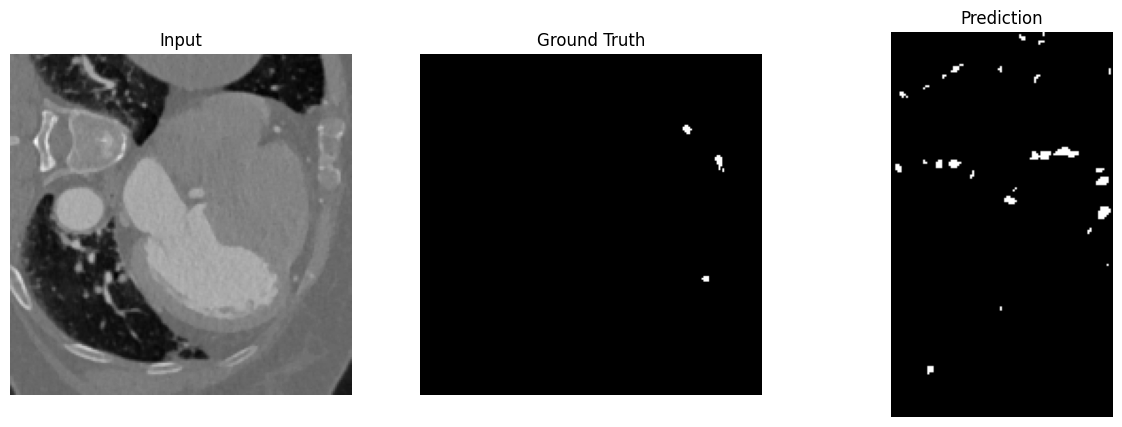

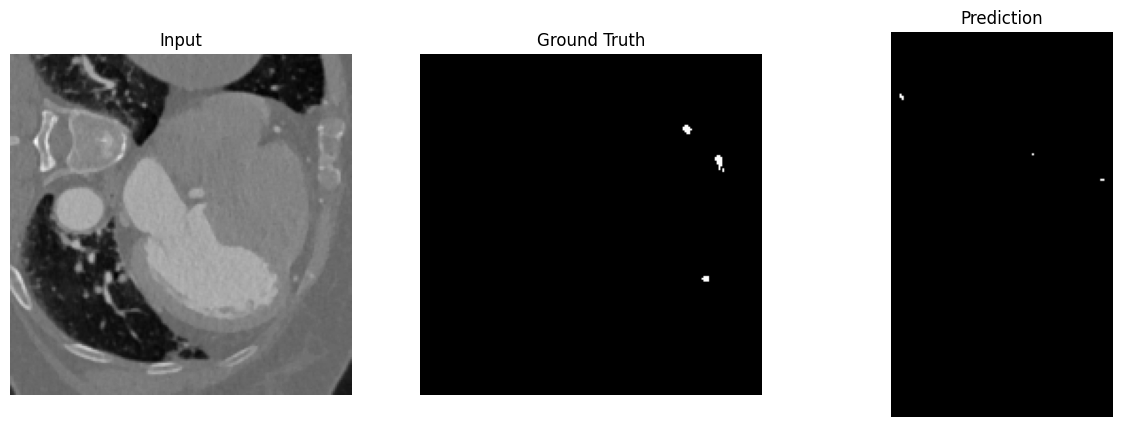

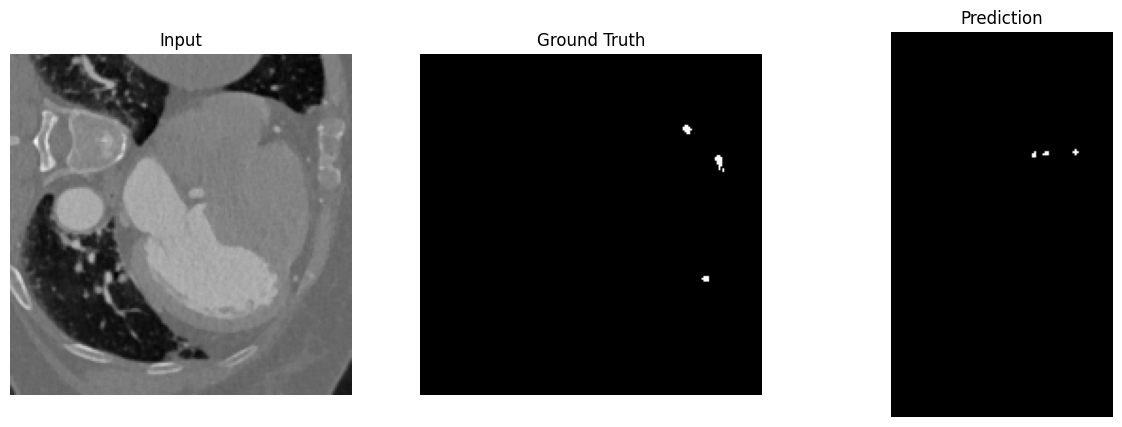

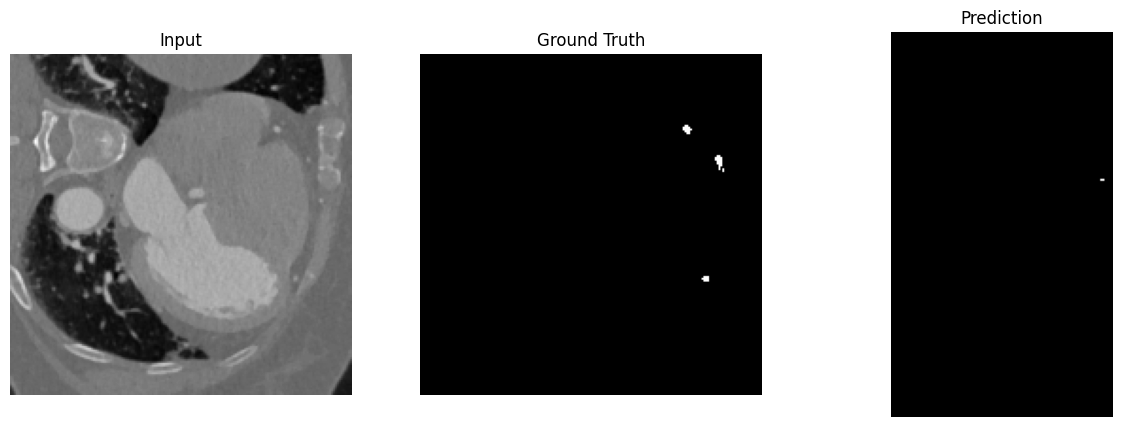

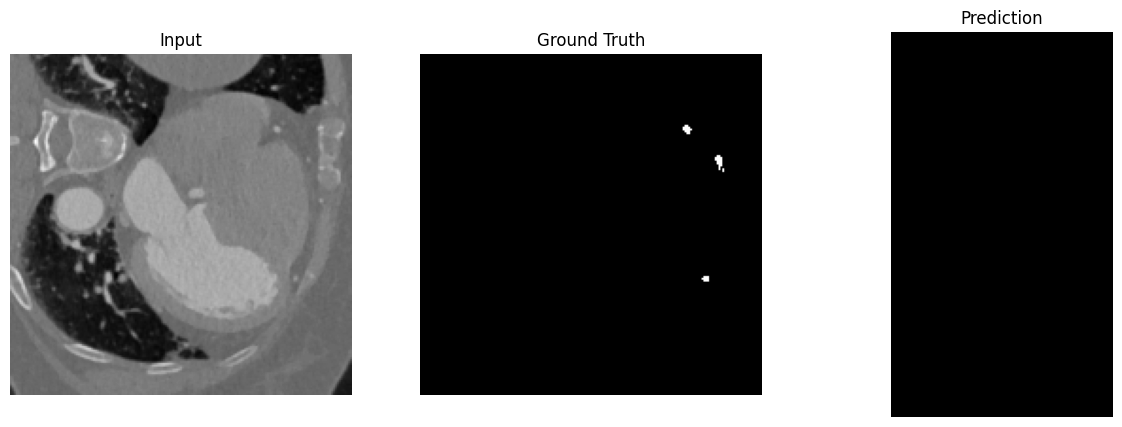

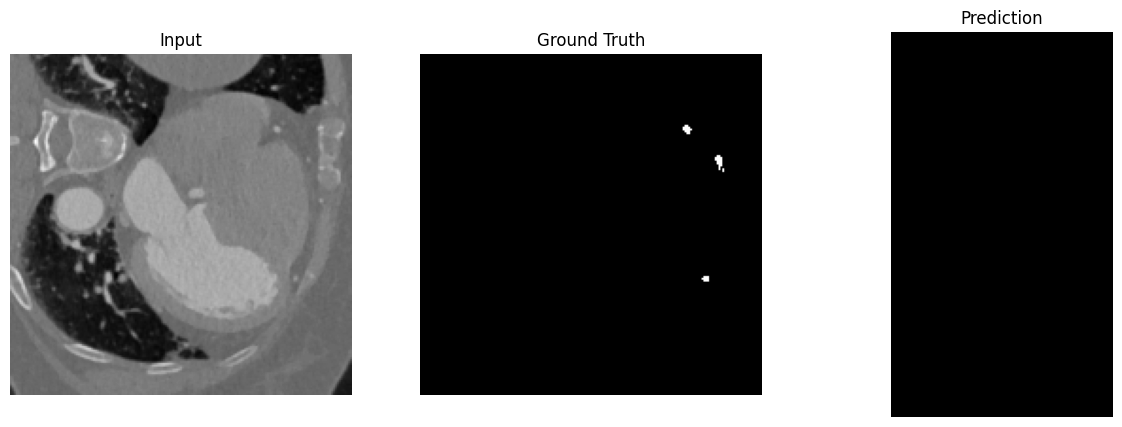

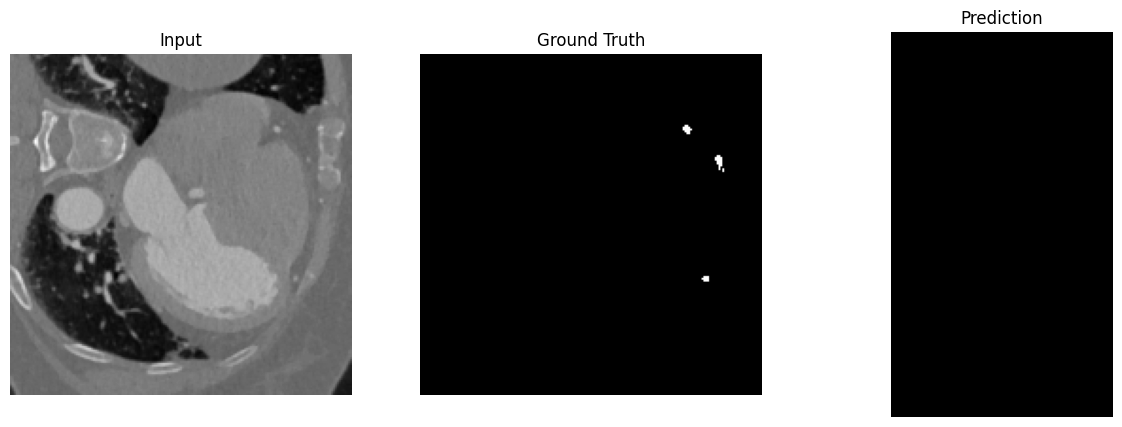

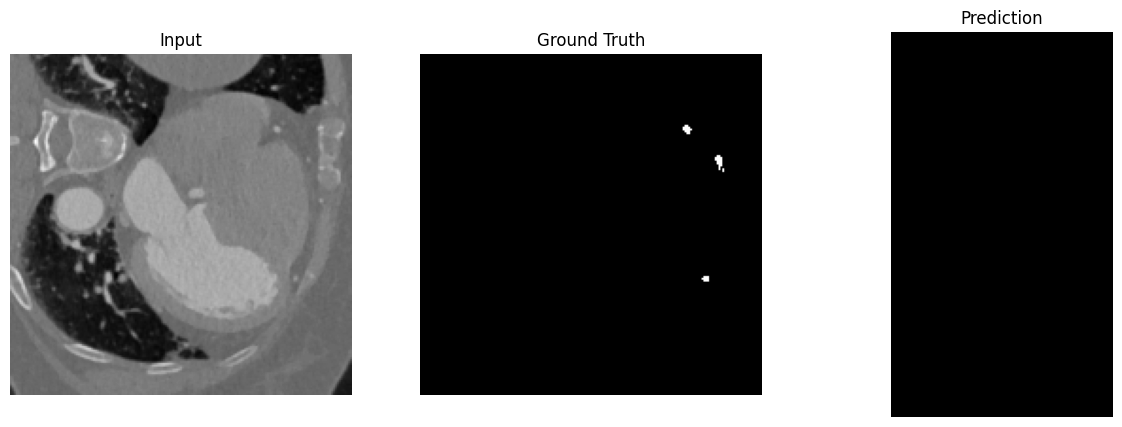

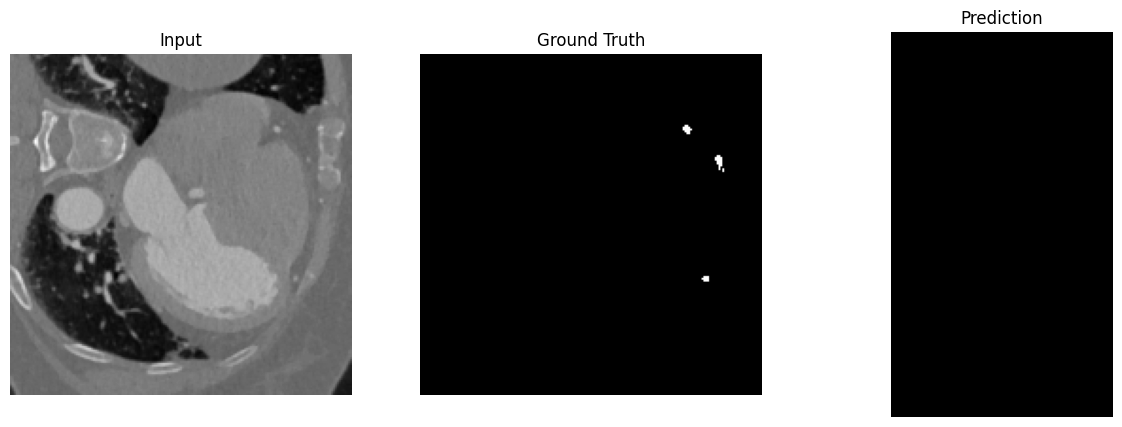

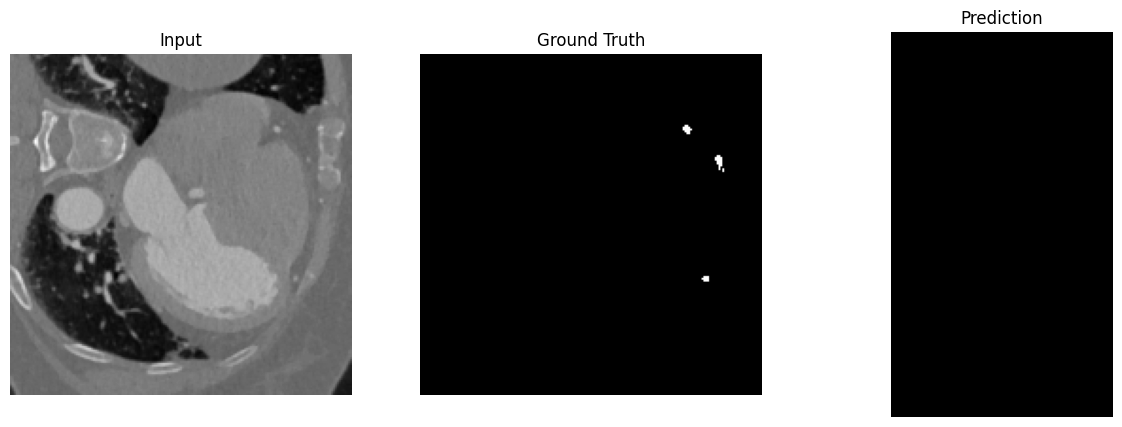

In [23]:
for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    start_time = time.time()
    for idx, batch_data in enumerate(train_loader):
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    # print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")
    print(
            "Epoch {}/{} {}/{}".format(epoch, max_epochs, idx, len(train_loader)),
            "loss: {:.4f}".format(epoch_loss),
            "time {:.2f}s".format(time.time() - start_time),
        )
    start_time = time.time()

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            epoch_dices = []
            for idx, val_data in enumerate(val_loader):
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                val_outputs = model_inferer(val_inputs)
                dice_val = dice(val_outputs, val_labels)
                epoch_dices.append(dice_val)
                
                print(f"{idx}/{len(val_ds)} dice: {dice_val:.4f}")

                
                if idx == 0:
                    pred = F.sigmoid(val_outputs) > 0.5
                    input_tensor = val_inputs[0].cpu()
                    label_tensor = val_labels[0].cpu()
                    pred_tensor = pred[0].cpu()

                    input_numpy= input_tensor.numpy()
                    label_numpy= label_tensor.numpy()
                    pred_numpy = pred_tensor.numpy()
                    
                    # Convert the output to a binary prediction
                    pred = F.sigmoid(val_outputs) > 0.5
                    # Move tensors to CPU and convert to numpy arrays
                    input_slice = val_inputs [0, 0, :,:, val_inputs.shape[4]//2].cpu().numpy() 
                    label_slice = val_labels [0, 0, :,:, val_labels.shape[4]//2].cpu().numpy() 
                    pred_slice = pred[0, 0, :, pred.shape[4]//2].cpu().numpy()
                    # Create a figure with three subplots
                    fig, (ax1, ax2, ax3)= plt.subplots(1, 3, figsize=(15, 5))
                    # Display the input image
                    ax1.imshow(input_slice, cmap='gray')
                    ax1.set_title('Input') 
                    ax1.axis('off')
                    # Display the ground truth 
                    ax2.imshow(label_slice, cmap='gray') 
                    ax2.set_title('Ground Truth')
                    ax2.axis('off')
                    # Display the prediction
                    ax3.imshow(pred_slice, cmap='gray')
                    ax3.set_title('Prediction')
                    ax3.axis('off')

                
            dice_epoch = torch.stack(epoch_dices).mean()

            metric_values.append(dice_epoch)
            if dice_epoch > best_metric:
                best_metric = dice_epoch
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_metric_model.pth")
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {dice_epoch:.4f} "
                f"best mean dice: {best_metric:.4f} at epoch: {best_metric_epoch}")

save_image = transforms.SaveImage(output_dir="/kaggle/working/", output_postfix="input", resample=False, separate_folder=False)
save_image(input_numpy)
save_image = transforms.SaveImage(output_dir="/kaggle/working/", output_postfix="ground truth", resample=False, separate_folder=False)
save_image(label_numpy)
save_image = transforms.SaveImage(output_dir="/kaggle/working/", output_postfix="prediction", resample=False, separate_folder=False)
save_image(pred_numpy)

In [24]:
numpy_metrics = np.array([tensor.cpu().numpy() for tensor in metric_values])

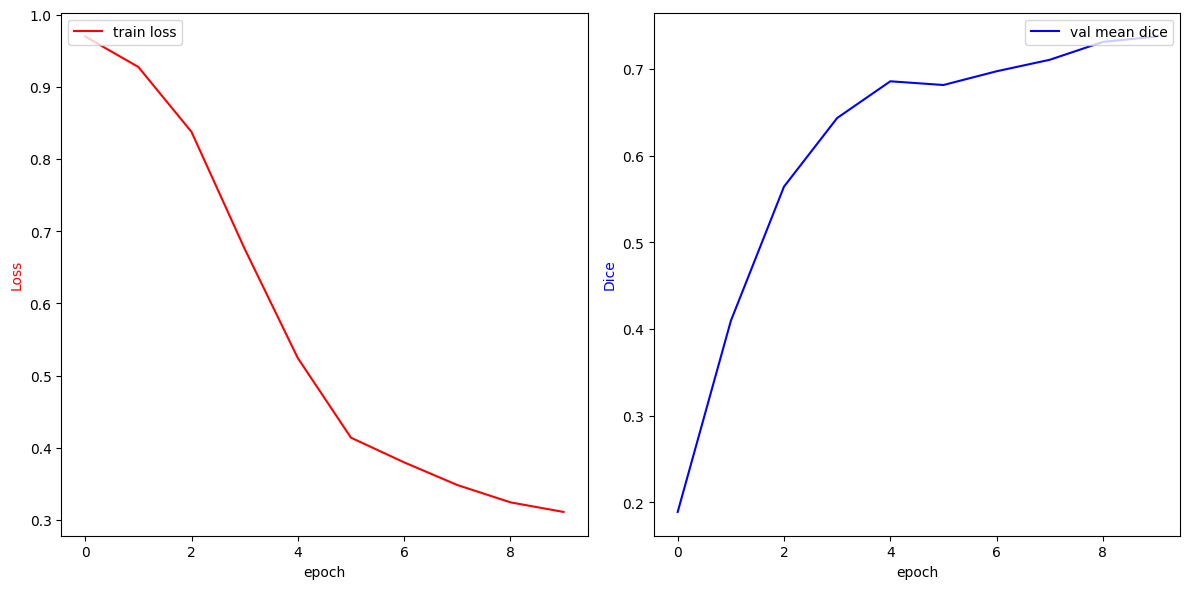

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot for train loss
ax1.plot(range(max_epochs), epoch_loss_values, "r", label="train loss")
ax1.set_xlabel("epoch", color="k")
ax1.set_ylabel("Loss", color="r")
ax1.legend(loc="upper left")

# Plot for validation mean dice
ax2.plot(range(max_epochs), numpy_metrics, "b", label="val mean dice")
ax2.set_xlabel("epoch", color="k")
ax2.set_ylabel("Dice", color="b")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [26]:
model_inferer = partial(
    sliding_window_inference,
    roi_size=[roi[0], roi[1], roi[2]],
    sw_batch_size=sw_batch_size,
    predictor=model,
    overlap=infer_overlap,
    sw_device="cpu",
)

val_transform = transforms.Compose(
    [
        transforms.LoadImaged(keys=["image", "label"], ensure_channel_first=True),
        transforms.SpatialPadd(keys=["image", "label"], spatial_size=roi),
    ]
)

val_ds = data.Dataset(data=validation_files, transform=val_transform)
val_loader = data.DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
)

In [27]:
sample = next(iter(val_loader))

In [28]:
# Set the model to evaluation mode
model.eval()

# Create a list to store the predicted masks
predicted_masks = []

# Get the first sample from the validation dataset
val_data = sample

# Move the data to the device (GPU if available)
val_inputs = val_data["image"].to(device)

# Perform inference using sliding window
val_outputs = model_inferer(val_inputs)

# Apply activation function to the outputs
val_outputs = Activations(sigmoid=True)(val_outputs)

# Convert the predicted masks to discrete values
val_outputs = AsDiscrete(argmax=False, threshold=0.5)(val_outputs)

# Convert the predicted masks to numpy array
predicted_masks = val_outputs.cpu().numpy()

# Print the shape of the predicted masks
print("Shape of predicted masks:", predicted_masks.shape)

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [ ]:
plt.imshow(predicted_masks[0, 0, :,:, 50], cmap='gray')